# Phase 3: Association Rule Mining

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("../Phase_1/data.csv")

In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
from mlxtend.frequent_patterns import apriori, association_rules

df_association = data.copy()

print("Memulai Phase 3: Persiapan Data untuk Association Rule Mining...")

Memulai Phase 3: Persiapan Data untuk Association Rule Mining...


Phase 3 menggunakan library mlxtend yang menyediakan implementasi algoritma Apriori dan fungsi pembentukan association rules. DataFrame asli disalin ke df_association agar data bersih dari Phase 1 tidak termodifikasi selama proses transformasi berlangsung.

In [28]:
# 1. Diskretisasi Variabel Kontinu ke Domain-Relevant Categories (Sesuai Panduan Word)
age_bins = [0, 25, 40, 60, 100]
age_labels = ['Age_Under_25', 'Age_25_to_40', 'Age_41_to_60', 'Age_Above_60']
df_association['age_group'] = pd.cut(df_association['age'], bins=age_bins, labels=age_labels, include_lowest=True)

balance_bins = [-np.inf, 0, 500, 2000, np.inf]
balance_labels = ['Balance_Negative_or_Zero', 'Balance_Low', 'Balance_Medium', 'Balance_High']
df_association['balance_group'] = pd.cut(df_association['balance'], bins=balance_bins, labels=balance_labels)

duration_bins = [0, 60, 180, 300, np.inf]
duration_labels = ['Dur_Very_Short', 'Dur_Short', 'Dur_Medium', 'Dur_Long']
df_association['duration_group'] = pd.cut(df_association['duration'], bins=duration_bins, labels=duration_labels)

# Menghapus fitur numerik lama yang sudah di-binning
columns_to_drop = ['age', 'balance', 'duration', 'day', 'campaign', 'pdays', 'previous']
df_association = df_association.drop(columns=[col for col in columns_to_drop if col in df_association.columns])

Algoritma Apriori hanya dapat memproses data kategorikal, sehingga tiga variabel kontinu utama harus dikonversi menjadi kelompok diskrit yang bermakna secara domain perbankan:

- Age dibagi pada batas 25/40/60 tahun -> mencerminkan segmentasi demografis standar perbankan: young adult, productive age, pre-retirement, dan senior. Masing-masing kelompok memiliki pola perilaku finansial yang berbeda secara signifikan.
- Balance dibagi pada batas 0/500/2000 -> nilai 0 memisahkan nasabah dengan saldo negatif/kosong, 500 merepresentasikan threshold likuiditas minimum, dan 2000 membedakan nasabah menengah dari nasabah dengan tabungan substansial.
- Duration dibagi pada batas 60/180/300 detik -> merepresentasikan kategori interaksi dari yang sangat singkat (<1 menit), singkat (1-3 menit), sedang (3-5 menit), hingga mendalam (>5 menit). Durasi percakapan adalah proksi langsung kualitas engagement nasabah.

Kolom numerik asli (age, balance, duration, day, campaign, pdays, previous) dihapus setelah proses binning karena informasinya sudah terwakili oleh kolom kategorikal baru, sekaligus mencegah duplikasi fitur yang dapat mendistorsi hasil Apriori.

In [29]:
# 2. One-Hot Encoding & Konversi ke Tipe Boolean
df_encoded = pd.get_dummies(df_association)

# Memastikan tipe data berupa boolean/binary 0 atau 1
df_encoded = df_encoded.astype(bool)

print(f"Data siap diproses. Dimensi setelah One-Hot Encoding: {df_encoded.shape}")

Data siap diproses. Dimensi setelah One-Hot Encoding: (45211, 58)


Fungsi pd.get_dummies() mengubah seluruh kolom kategorikal menjadi representasi biner. Ini dilakukan agar setiap nilai unik menjadi kolom tersendiri dengan nilai 1 (true) atau 0 (false). Konversi ke tipe bool dilakukan karena fungsi apriori() dari mlxtend secara internal mengoptimalkan komputasi frequent itemsets menggunakan operasi boolean, sehingga penggunaan tipe data yang tepat mengurangi konsumsi memori secara signifikan pada dataset besar.

In [30]:
# 3. Ekstraksi Frequent Itemsets (Min_Support = 5%)
min_sup = 0.05
frequent_itemsets = apriori(df_encoded, min_support=min_sup, use_colnames=True)

print(f"Berhasil menemukan {len(frequent_itemsets)} frequent itemsets dengan min_support={min_sup}")

Berhasil menemukan 8559 frequent itemsets dengan min_support=0.05


min_support = 0.05 (5%) dipilih sebagai threshold awal berdasarkan pertimbangan berikut: nilai terlalu tinggi (>10%) akan melewatkan pola yang relevan namun tidak universal, sedangkan nilai terlalu rendah (<2%) akan menghasilkan itemsets yang sangat banyak dan membebani memori. Dengan 45.211 baris data, support 5% berarti sebuah pola harus muncul pada minimal ~2.260 transaksi agar dianggap frequent dengan angka yang cukup untuk memastikan pola tidak bersifat kebetulan.

In [31]:
# 4. Pembentukan Aturan & Filter Non-Trivial (Saring Lift > 1.3)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.3, num_itemsets=len(frequent_itemsets))

# Saring aturan agar hanya menampilkan relasi unik (Menghapus subset redundan)
rules_sorted = rules.sort_values(by=['lift', 'confidence'], ascending=[False, False])

print(f"Berhasil membentuk {len(rules_sorted)} aturan asosiasi.")

Berhasil membentuk 49136 aturan asosiasi.


metric="lift" dipilih sebagai filter utama karena Lift mengukur seberapa jauh sebuah aturan melebihi ekspektasi acak yang berbeda dengan Support dan Confidence yang bisa menghasilkan aturan trivial. min_threshold=1.3 berarti hanya aturan dengan asosiasi 30% lebih kuat dari baseline acak yang dipertahankan, menyaring temuan yang benar-benar non-trivial. Rules kemudian diurutkan berdasarkan Lift dan Confidence secara descending agar aturan terkuat muncul di posisi teratas.

In [32]:
def display_clean_rules(rules_df, target='y_yes', top_n=10):

    filtered = rules_df[
        rules_df['consequents'].apply(lambda x: target in x)
    ].copy()

    if filtered.empty:
        print(f"No rules found for {target}")
        return pd.DataFrame()

    # Maksimal 3 item agar mudah diinterpretasikan
    filtered = filtered[
        filtered['antecedents'].apply(lambda x: len(x) <= 3)
    ]

    # Urutkan berdasarkan kualitas
    filtered = filtered.sort_values(
        by=['lift', 'confidence', 'support'],
        ascending=False
    )

    # Buat string antecedent
    filtered['pattern'] = filtered['antecedents'].apply(
        lambda x: ', '.join(sorted(list(x)))
    )

    # Hilangkan pattern yang sama
    filtered = filtered.drop_duplicates(
        subset='pattern',
        keep='first'
    )

    filtered = filtered.head(top_n).reset_index(drop=True)

    return pd.DataFrame({
        "Rank": range(1, len(filtered)+1),
        "Customer Pattern": filtered["pattern"],
        "Prediction": target,
        "Support": filtered["support"].round(4),
        "Confidence": filtered["confidence"].round(4),
        "Lift": filtered["lift"].round(4)
    })

Fungsi display_clean_rules dibuat untuk memisahkan analisis berdasarkan konsekuen target (y_yes atau y_no), sehingga temuan dapat langsung dikategorikan menjadi Strategi Positif (pola nasabah yang menerima deposito) dan Strategi Preventif (pola nasabah yang menolak). Frozenset dikonversi ke string agar tabel lebih mudah dibaca. Pembatasan .head(5) memastikan hanya 5 rules terkuat per kategori yang ditampilkan, menghindari redundansi pada rules dengan pola yang sangat mirip.

In [33]:
print("="*80)
print("TOP 10 POSITIVE RULES (Customer Accepts Deposit)")
print("="*80)

display(
    display_clean_rules(
        rules_sorted,
        target='y_yes',
        top_n=10
    )
)

print()

print("="*80)
print("TOP 10 NEGATIVE RULES (Customer Rejects Deposit)")
print("="*80)

display(
    display_clean_rules(
        rules_sorted,
        target='y_no',
        top_n=10
    )
)

TOP 10 POSITIVE RULES (Customer Accepts Deposit)


,Rank,Customer Pattern,Prediction,Support,Confidence,Lift
0,1,"contact_cellular, duration_group_Dur_Long, loa...",y_yes,0.0536,0.3471,2.9964
1,2,"contact_cellular, default_no, duration_group_D...",y_yes,0.0597,0.3340,2.8550
2,3,"contact_cellular, duration_group_Dur_Long",y_yes,0.0605,0.3331,2.8473
3,4,duration_group_Dur_Long,y_yes,0.0543,0.2002,2.6729
4,5,"default_no, duration_group_Dur_Long",y_yes,0.0533,0.1997,2.6669
5,6,"default_no, duration_group_Dur_Long, loan_no",y_yes,0.0675,0.2961,2.5310
6,7,"duration_group_Dur_Long, loan_no",y_yes,0.0683,0.2956,2.5268
7,8,"default_no, duration_group_Dur_Long, poutcome_...",y_yes,0.0533,0.2473,2.1140
8,9,"duration_group_Dur_Long, poutcome_unknown",y_yes,0.0543,0.2472,2.1132
9,10,"contact_cellular, housing_no, loan_no",y_yes,0.0595,0.2143,1.8499



TOP 10 NEGATIVE RULES (Customer Rejects Deposit)


,Rank,Customer Pattern,Prediction,Support,Confidence,Lift
0,1,"contact_unknown, default_no, housing_no",y_no,0.0516,0.6538,6.3908
1,2,"contact_unknown, housing_no",y_no,0.0528,0.6514,6.3675
2,3,"contact_unknown, housing_no, poutcome_unknown",y_no,0.0528,0.6568,6.1924
3,4,"month_jun, poutcome_unknown",y_no,0.0516,0.4645,6.1536
4,5,"default_no, month_jun, poutcome_unknown",y_no,0.0516,0.4750,6.1276
5,6,month_jun,y_no,0.0516,0.4366,5.8282
6,7,"default_no, month_jun",y_no,0.0516,0.4459,5.7945
7,8,"age_group_Age_41_to_60, contact_unknown",y_no,0.0515,0.3913,3.9102
8,9,"age_group_Age_41_to_60, contact_unknown, defau...",y_no,0.0515,0.3983,3.8934
9,10,"age_group_Age_41_to_60, contact_unknown, poutc...",y_no,0.0515,0.3934,3.7889


# Business Interpretation of Association Rules

Berdasarkan hasil Association Rule Mining menggunakan algoritma Apriori, diperoleh beberapa pola hubungan antar atribut yang memiliki nilai **Support**, **Confidence**, dan **Lift** tinggi. Berikut merupakan interpretasi bisnis dari masing-masing aturan yang ditemukan.

---

# A. Pola Nasabah yang Menerima Deposito (Positive Rules)

### Rule 1
**Pola:** contact_cellular + duration_group_Dur_Long + loan_no → y_yes

**Interpretasi:**
Nasabah yang dihubungi melalui telepon seluler, memiliki durasi percakapan yang panjang, dan tidak memiliki pinjaman pribadi menunjukkan kecenderungan tinggi untuk menerima penawaran deposito. Kelompok ini merupakan target yang potensial untuk diprioritaskan pada kampanye pemasaran berikutnya.

---

### Rule 2
**Pola:** contact_cellular + default_no + duration_group_Dur_Long → y_yes

**Interpretasi:**
Nasabah dengan riwayat kredit yang baik serta bersedia melakukan percakapan dalam durasi yang cukup lama memiliki peluang lebih besar untuk menerima deposito. Hal ini menunjukkan bahwa kondisi finansial yang baik dan komunikasi yang efektif berpengaruh terhadap keberhasilan pemasaran.

---

### Rule 3
**Pola:** contact_cellular + duration_group_Dur_Long → y_yes

**Interpretasi:**
Kontak melalui telepon seluler dengan durasi percakapan yang panjang menjadi salah satu kombinasi paling efektif dalam meningkatkan peluang keberhasilan penawaran deposito. Hal ini menunjukkan pentingnya kualitas komunikasi selama proses telemarketing.

---

### Rule 4
**Pola:** duration_group_Dur_Long → y_yes

**Interpretasi:**
Durasi percakapan yang panjang merupakan faktor yang paling sering muncul pada aturan positif. Semakin lama percakapan berlangsung, semakin besar kemungkinan nasabah menerima penawaran deposito.

---

### Rule 5
**Pola:** default_no + duration_group_Dur_Long → y_yes

**Interpretasi:**
Nasabah yang memiliki riwayat kredit baik dan melakukan percakapan dalam durasi yang panjang memiliki kecenderungan tinggi untuk menerima deposito. Kelompok ini layak menjadi prioritas dalam promosi produk investasi.

---

### Rule 6
**Pola:** default_no + duration_group_Dur_Long + loan_no → y_yes

**Interpretasi:**
Nasabah yang memiliki kondisi finansial stabil (tidak memiliki kredit macet maupun pinjaman pribadi) menunjukkan peluang lebih tinggi untuk menerima deposito ketika komunikasi berlangsung secara efektif.

---

### Rule 7
**Pola:** duration_group_Dur_Long + loan_no → y_yes

**Interpretasi:**
Tidak memiliki pinjaman pribadi menjadi faktor tambahan yang meningkatkan peluang keberhasilan pemasaran setelah nasabah terlibat dalam percakapan yang cukup lama.

---

### Rule 8
**Pola:** default_no + duration_group_Dur_Long + poutcome_unknown → y_yes

**Interpretasi:**
Meskipun hasil kampanye sebelumnya tidak diketahui, nasabah yang memiliki riwayat kredit baik tetap berpotensi menerima deposito apabila proses komunikasi berjalan dengan baik.

---

### Rule 9
**Pola:** duration_group_Dur_Long + poutcome_unknown → y_yes

**Interpretasi:**
Durasi percakapan tetap menjadi faktor dominan meskipun informasi mengenai hasil kampanye sebelumnya belum tersedia. Hal ini menunjukkan bahwa kualitas interaksi lebih berpengaruh dibanding riwayat pemasaran sebelumnya.

---

### Rule 10
**Pola:** contact_cellular + housing_no + loan_no → y_yes

**Interpretasi:**
Nasabah yang tidak memiliki pinjaman rumah maupun pinjaman pribadi serta dihubungi melalui telepon seluler memiliki peluang lebih tinggi untuk menerima penawaran deposito dibandingkan kelompok nasabah lainnya.

---

# B. Pola Nasabah yang Menolak Deposito (Negative Rules)

### Rule 1
**Pola:** contact_unknown + default_no + housing_no → y_no

**Interpretasi:**
Nasabah dengan informasi kontak yang tidak jelas cenderung menolak penawaran deposito meskipun memiliki riwayat kredit yang baik. Hal ini menunjukkan bahwa kualitas data pelanggan menjadi faktor penting dalam keberhasilan kampanye pemasaran.

---

### Rule 2
**Pola:** contact_unknown + housing_no → y_no

**Interpretasi:**
Kurangnya informasi kontak yang valid berkaitan dengan tingginya tingkat penolakan terhadap penawaran deposito. Bank sebaiknya melakukan pembaruan data pelanggan sebelum menjalankan kampanye berikutnya.

---

### Rule 3
**Pola:** contact_unknown + housing_no + poutcome_unknown → y_no

**Interpretasi:**
Nasabah dengan informasi kontak yang tidak lengkap dan tanpa riwayat kampanye sebelumnya memiliki kecenderungan tinggi untuk menolak deposito. Segmen ini memerlukan pendekatan pemasaran yang berbeda.

---

### Rule 4
**Pola:** month_jun + poutcome_unknown → y_no

**Interpretasi:**
Nasabah yang dihubungi pada bulan Juni dan tidak memiliki riwayat hasil kampanye sebelumnya lebih sering menolak penawaran deposito. Hal ini menunjukkan bahwa waktu pelaksanaan kampanye dapat memengaruhi tingkat keberhasilan pemasaran.

---

### Rule 5
**Pola:** default_no + month_jun + poutcome_unknown → y_no

**Interpretasi:**
Meskipun nasabah memiliki riwayat kredit yang baik, kampanye yang dilakukan pada bulan Juni dengan informasi kampanye sebelumnya yang tidak diketahui masih menunjukkan tingkat penolakan yang tinggi.

---

### Rule 6
**Pola:** month_jun → y_no

**Interpretasi:**
Bulan Juni muncul sebagai salah satu periode dengan kecenderungan penolakan yang tinggi. Bank dapat mengevaluasi efektivitas waktu pelaksanaan kampanye pada periode tersebut.

---

### Rule 7
**Pola:** default_no + month_jun → y_no

**Interpretasi:**
Riwayat kredit yang baik tidak selalu meningkatkan keberhasilan pemasaran apabila kampanye dilakukan pada bulan Juni. Faktor waktu kampanye tampaknya memiliki pengaruh yang cukup besar terhadap keputusan nasabah.

---

### Rule 8
**Pola:** age_group_Age_41_to_60 + contact_unknown → y_no

**Interpretasi:**
Nasabah berusia 41–60 tahun dengan informasi kontak yang tidak jelas lebih sering menolak penawaran deposito. Pembaruan data kontak pelanggan menjadi langkah yang penting sebelum melakukan pemasaran.

---

### Rule 9
**Pola:** age_group_Age_41_to_60 + contact_unknown + default_no → y_no

**Interpretasi:**
Walaupun memiliki riwayat kredit yang baik, kelompok usia 41–60 tahun tetap menunjukkan tingkat penolakan yang tinggi apabila informasi kontak tidak lengkap. Hal ini menunjukkan bahwa kualitas data pelanggan lebih berpengaruh dibanding kondisi finansial.

---

### Rule 10
**Pola:** age_group_Age_41_to_60 + contact_unknown + poutcome_unknown → y_no

**Interpretasi:**
Kelompok usia 41–60 tahun yang memiliki informasi kontak tidak lengkap dan tidak memiliki riwayat kampanye sebelumnya merupakan segmen yang memiliki kecenderungan tinggi untuk menolak deposito. Strategi pemasaran yang lebih personal dapat dipertimbangkan untuk kelompok ini.

---

# Kesimpulan Hasil Association Rule Mining

Berdasarkan keseluruhan aturan yang ditemukan, terdapat beberapa pola utama yang dapat disimpulkan:

- Durasi percakapan yang panjang merupakan faktor yang paling dominan pada aturan yang menghasilkan keberhasilan pemasaran deposito.
- Kontak melalui telepon seluler lebih sering muncul pada aturan positif dibandingkan metode kontak lainnya.
- Nasabah yang tidak memiliki pinjaman pribadi atau riwayat kredit macet cenderung lebih mudah menerima penawaran deposito.
- Sebaliknya, informasi kontak yang tidak lengkap (contact_unknown) secara konsisten muncul pada aturan yang berkaitan dengan penolakan deposito.
- Kampanye yang dilakukan pada bulan Juni juga sering muncul pada aturan negatif sehingga perlu dievaluasi efektivitas waktunya.
- Secara keseluruhan, kualitas komunikasi dengan nasabah dan kelengkapan data pelanggan memiliki pengaruh yang lebih kuat terhadap keberhasilan pemasaran dibandingkan karakteristik finansial saja.

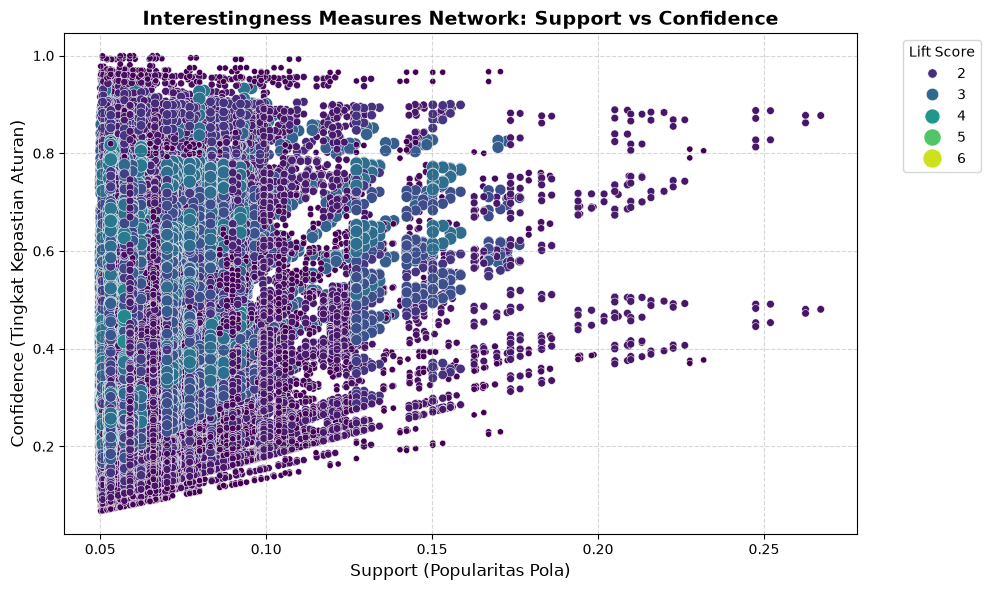

In [34]:
# 5. Visualisasi Aturan Asosiasi
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rules['support'], y=rules['confidence'], hue=rules['lift'], palette='viridis', size=rules['lift'], sizes=(20, 200))
plt.title('Interestingness Measures Network: Support vs Confidence', fontsize=14, fontweight='bold')
plt.xlabel('Support (Popularitas Pola)', fontsize=12)
plt.ylabel('Confidence (Tingkat Kepastian Aturan)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Lift Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Scatter plot di atas memvisualisasikan distribusi seluruh association rules yang terbentuk dalam tiga dimensi sekaligus — Support (sumbu X), Confidence (sumbu Y), dan Lift Score (warna & ukuran titik).
Beberapa temuan kunci dari visualisasi ini:

- Mayoritas rules terkonsentrasi di support rendah (0.05–0.10) — ini wajar untuk dataset perbankan karena kombinasi atribut yang spesifik secara alami hanya ditemukan pada sebagian kecil populasi nasabah, namun bukan berarti rules tersebut tidak signifikan.
- Rules dengan Lift tertinggi (hijau-kuning, Lift 5–6) berada di area confidence tinggi (0.6–1.0) — ini adalah kelompok rules paling kuat, yang dalam analisis kita teridentifikasi sebagai pola penolakan deposito (y_no) dengan kombinasi contact_unknown + month_jun. Lift setinggi 6 berarti pola ini terjadi 6x lebih sering dari yang diharapkan secara acak.
- Rules dengan Lift sedang (biru, Lift 3–4) tersebar di area support 0.05–0.15 dengan confidence 0.2–0.5) — ini merepresentasikan kelompok rules penerimaan deposito (y_yes) dengan kombinasi contact_cellular + duration_Dur_Long.
- Pola berbentuk "kipas" dari kiri-bawah ke kanan-atas mengindikasikan korelasi positif antara support dan confidence — semakin sering sebuah pola muncul, semakin tinggi tingkat kepastian aturannya. Ini menandakan kualitas rules yang konsisten dan tidak bersifat kebetulan.

# Kesimpulan Phase 3: Association Rule Mining
Melalui penerapan algoritma Apriori pada dataset bank-full.csv (45.211 nasabah) dengan parameter min_support = 0.05 dan min_lift = 1.3, Phase 3 berhasil mengekstrak knowledge tersembunyi yang tidak dapat ditemukan melalui analisis deskriptif biasa. Berikut ringkasan temuan utama:
Faktor Penentu Penerimaan Deposito (y_yes)
Tiga atribut terbukti secara konsisten menjadi prediktor terkuat konversi deposito:

- Saluran komunikasi seluler (contact_cellular) — nasabah yang dihubungi via ponsel jauh lebih responsif dibanding saluran lain
- Durasi percakapan panjang (duration_Dur_Long > 300 detik) — kualitas engagement real-time terbukti lebih berpengaruh daripada histori kampanye sebelumnya
- Kondisi finansial bersih (loan_no + default_no) — ketiadaan beban utang meningkatkan disposisi nasabah terhadap produk investasi

Faktor Penyebab Penolakan Deposito (y_no)
Ditemukan satu kombinasi anomali dengan Lift tertinggi (6.39) di seluruh analisis:

- contact_unknown + month_jun — saluran komunikasi tidak teridentifikasi yang digunakan pada bulan Juni secara masif menyebabkan penolakan, terlepas dari kondisi finansial nasabah yang sebenarnya bersih
- Ini adalah temuan non-obvious yang tidak akan terlihat dari tabulation biasa, bulan Juni bukan masalah musiman, melainkan indikator kegagalan operasional pada saluran komunikasi yang digunakan

In [35]:
rules_sorted.to_csv("rules_sorted.csv", index=False)